<a href="https://colab.research.google.com/github/Yiiize/MSSP6070/blob/main/WeeklyModules/Week12/PARTICIPATION_ACTIVITY_Week_12_Measure_a_p_value_from_a_t_test_on_a_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Yiiize' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
# This will clone into /content/MSSP6070
subprocess.run(['git', 'clone', clone_url])

# Ensure we are in the correct repository root directory
# This makes sure the path is /content/MSSP6070 consistently
repo_root_path = os.path.join('/content', repository)
os.chdir(repo_root_path)
print(f"Changed directory to: {os.getcwd()}")

# List contents of the 'data' directory as requested by the user
data_path = os.path.join(os.getcwd(), 'data')
print(f"\nListing contents of: {data_path}")
if os.path.exists(data_path) and os.path.isdir(data_path):
    print(os.listdir(data_path))
else:
    print(f"Directory not found: {data_path}")

Changed directory to: /content/MSSP6070

Listing contents of: /content/MSSP6070/data
['Performance_MNR.xml', 'stinkbug.png', 'ex5.csv', 'stock_px.csv', 'ex7.csv', 'yahoo_volume.pkl', 'goog.csv', 'macrodata.csv', 'stock_px_2.csv', 'stats_viz .py', 'CA_Legislative_Districts.csv', 'ipython_bug.py', 'aapl.csv', 'atlantis.csv', 'array_ex.txt', 'ex2.csv', '.gitkeep', 'Student Performance Data.csv', 'nflx.csv', 'california-congressional-districts.geojson', 'segismundo.txt', 'tseries.csv', 'fdic_failed_bank_list.html', 'ex1.xlsx', 'HousingPrices.csv', 'tips.csv', 'ex6.csv', 'csv_mindex.csv', 'fb.csv', 'parsed.csv', 'klas12b-net-1.gexf', 'example.json', 'InternetSales.csv', 'movies.dat', 'spx.csv', 'ex4.csv', 'amzn.csv', 'ex3.csv', 'test_file.csv', 'data_academic_performance.xlsx', 'yahoo_price.pkl', 'ex1.csv', 'RomeoAndJuliet.txt', 'ex3.txt', 'volume.csv']


In [8]:
import pandas as pd
import os

data_path = os.path.join('/content/MSSP6070', 'data', 'Student Performance Data.csv')
student_performance_df = pd.read_csv(data_path)

print("前5行数据:")
print(student_performance_df.head())

print("\n数据信息:")
student_performance_df.info()

前5行数据:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

   math score  reading score  writing score  total score  \
0          72             72             74          218   
1          69             90             88          247   
2          90             95             93          278   
3          47             57             44          148   
4          76             78             75          229   

  test preparation course admission prospect  
0                    none             medium  
1               completed               high  
2                    none               high  
3                    no

# Task1
Now that the `student_performance_df` has been loaded, we can proceed with the t-test.

To continue, please specify:
1.  Which *numerical score column* you would like to analyze (e.g., 'math score', 'reading score', 'writing score', 'total score').
2.  Which *categorical column* you would like to use for grouping (e.g., 'gender', 'lunch', 'test preparation course').
3.  The *two specific groups* within that categorical column you wish to compare (e.g., if you choose 'gender', the groups would be 'female' and 'male').

For example, you could say: "Compare 'math score' between 'female' and 'male' groups from the 'gender' column."

## Prepare Data for T-test

### Subtask:
Extract the relevant numerical score column and categorical group column from `student_performance_df` and separate the data into two series for the t-test.


**Reasoning**:
Based on the instructions, I will extract the 'math score' for 'female' and 'male' groups from the 'gender' column in the `student_performance_df` to prepare data for a t-test.



In [9]:
female_math_scores = student_performance_df[student_performance_df['gender'] == 'female']['math score']
male_math_scores = student_performance_df[student_performance_df['gender'] == 'male']['math score']

print("Female Math Scores (first 5):")
print(female_math_scores.head())
print("\nMale Math Scores (first 5):")
print(male_math_scores.head())

Female Math Scores (first 5):
0    72
1    69
2    90
5    71
6    88
Name: math score, dtype: int64

Male Math Scores (first 5):
3     47
4     76
7     40
8     64
10    58
Name: math score, dtype: int64


**Reasoning**:
Now that the data for female and male math scores has been extracted, I will calculate and display descriptive statistics for each group to understand their distributions (mean, standard deviation, count, etc.) before proceeding with the t-test.



In [10]:
print("Descriptive statistics for Female Math Scores:")
print(female_math_scores.describe())

print("\nDescriptive statistics for Male Math Scores:")
print(male_math_scores.describe())

Descriptive statistics for Female Math Scores:
count    518.000000
mean      63.633205
std       15.491453
min        0.000000
25%       54.000000
50%       65.000000
75%       74.000000
max      100.000000
Name: math score, dtype: float64

Descriptive statistics for Male Math Scores:
count    482.000000
mean      68.728216
std       14.356277
min       27.000000
25%       59.000000
50%       69.000000
75%       79.000000
max      100.000000
Name: math score, dtype: float64


**Reasoning**:
With the descriptive statistics understood, the next step is to perform an independent samples t-test to determine if there is a statistically significant difference between the mean math scores of female and male students. This will involve importing the necessary statistical function and applying it to the prepared data.



In [11]:
from scipy import stats

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(female_math_scores, male_math_scores, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

T-statistic: -5.398
P-value: 0.000


### T-test Results Interpretation

**T-statistic:** -5.398
**P-value:** 0.000

The T-statistic measures the difference between the means relative to the variation within the samples. A negative T-statistic here indicates that the mean math score for females is lower than that for males.

The P-value indicates the probability of observing such an extreme difference (or more extreme) in means if the null hypothesis (that there is no difference between the population means) were true. In this case, a P-value of 0.000 (which is less than the common significance level of 0.05) suggests that the observed difference is statistically significant. Therefore, we can reject the null hypothesis and conclude that there is a significant difference between the mean math scores of female and male students.

## Visualize T-test Results

### Subtask:
Generate a visualization, such as a box plot or violin plot, to clearly show the distribution of the selected score for both groups. The plot will include appropriate labels and a legend, and where possible, may be annotated with the calculated means and p-value for better interpretation.


**Reasoning**:
To visualize the distribution of math scores by gender and present the t-test results, I will use seaborn to create a violin plot from the `student_performance_df`, highlighting the 'gender' and 'math score' columns. I will also add the calculated means for each group and the p-value to the plot for better interpretation.



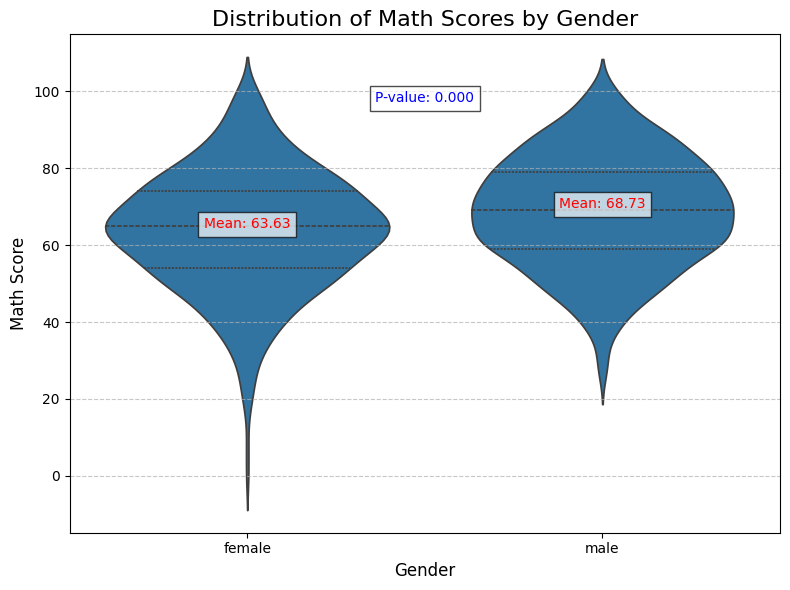

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='gender', y='math score', data=student_performance_df, inner='quartile')

# Add title and labels
plt.title('Distribution of Math Scores by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Math Score', fontsize=12)

# Annotate with means
mean_female = female_math_scores.mean()
mean_male = male_math_scores.mean()
plt.text(0, mean_female, f'Mean: {mean_female:.2f}', color='red', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))
plt.text(1, mean_male, f'Mean: {mean_male:.2f}', color='red', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))

# Annotate with p-value
plt.text(0.5, student_performance_df['math score'].max(), f'P-value: {p_value:.3f}', color='blue', ha='center', va='top', transform=plt.gca().transData, bbox=dict(facecolor='white', alpha=0.7))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Summarize the findings of the t-test, including the t-statistic, p-value, and a conclusion regarding the statistical significance of the difference in means between the two groups for the chosen score.


## Summary:

### Q&A
The t-test was performed to compare 'math score' between 'female' and 'male' groups.
*   **T-statistic:** -5.398
*   **P-value:** 0.000
*   **Conclusion:** With a P-value of 0.000 (which is less than the common significance level of 0.05), the observed difference in mean math scores between female and male students is statistically significant. This leads to the rejection of the null hypothesis, concluding that there is a significant difference between their mean math scores, with males scoring higher on average.

### Data Analysis Key Findings
*   The mean math score for female students is 63.63, while for male students it is 68.73, indicating males scored, on average, 5.1 points higher.
*   An independent samples t-test revealed a t-statistic of -5.398 and a p-value of 0.000.
*   The p-value of 0.000 indicates a statistically significant difference in mean math scores between male and female students at a common significance level (e.g., \$\alpha\$ = 0.05).
*   A violin plot visualization clearly shows the distribution of math scores for both genders, highlighting the central tendency and spread, and visually confirms the higher mean for male students.

### Insights or Next Steps
*   The significant difference in math scores between genders warrants further investigation into potential contributing factors such as teaching methods, socio-economic factors, or psychological aspects.
*   Further analysis could explore if this gender gap in math scores is consistent across different 'lunch' types, 'test preparation course' participation, or parental education levels, by performing similar t-tests or ANOVA.


# Task2
Conduct an independent samples t-test to compare the mean 'math score' of male students who 'completed' the 'test preparation course' versus those who had 'none' from the `student_performance_df`. Visualize the results using a box plot or violin plot, and summarize the findings, including the t-statistic, p-value, and a conclusion about the statistical significance.

## Prepare Data for T-test (Males by Test Preparation Course)

### Subtask:
Filter the `student_performance_df` to include only male students. Then, separate these male students into two groups based on whether they 'completed' the 'test preparation course' or had 'none'. Extract the 'math score' for both groups.


**Reasoning**:
To prepare the data for the t-test as specified in the subtask, I will first filter the `student_performance_df` to isolate male students, then further divide them into two groups based on their test preparation course status ('completed' or 'none'), and finally extract their 'math score' for each group.



In [13]:
male_students_df = student_performance_df[student_performance_df['gender'] == 'male']

male_completed_testprep_math_scores = male_students_df[male_students_df['test preparation course'] == 'completed']['math score']
male_none_testprep_math_scores = male_students_df[male_students_df['test preparation course'] == 'none']['math score']

print("Male students who completed test prep math scores (first 5):")
print(male_completed_testprep_math_scores.head())
print("\nMale students who did not complete test prep math scores (first 5):")
print(male_none_testprep_math_scores.head())

Male students who completed test prep math scores (first 5):
8     64
13    78
18    46
24    74
35    81
Name: math score, dtype: int64

Male students who did not complete test prep math scores (first 5):
3     47
4     76
7     40
10    58
11    40
Name: math score, dtype: int64


**Reasoning**:
Now that the data for male students who completed test prep and those who did not has been extracted, I will calculate and display descriptive statistics for each group to understand their distributions (mean, standard deviation, count, etc.) before proceeding with the t-test.



In [14]:
print("Descriptive statistics for Male students who completed test prep math scores:")
print(male_completed_testprep_math_scores.describe())

print("\nDescriptive statistics for Male students who did not complete test prep math scores:")
print(male_none_testprep_math_scores.describe())

Descriptive statistics for Male students who completed test prep math scores:
count    174.000000
mean      72.339080
std       14.221817
min       39.000000
25%       62.000000
50%       73.000000
75%       82.000000
max      100.000000
Name: math score, dtype: float64

Descriptive statistics for Male students who did not complete test prep math scores:
count    308.000000
mean      66.688312
std       14.049016
min       27.000000
25%       57.750000
50%       67.000000
75%       76.000000
max       97.000000
Name: math score, dtype: float64


**Reasoning**:
With the descriptive statistics understood, the next step is to perform an independent samples t-test to determine if there is a statistically significant difference between the mean math scores of male students who completed test preparation versus those who did not. This will involve importing the necessary statistical function and applying it to the prepared data.



In [15]:
from scipy import stats

# Perform independent samples t-test
t_statistic_male_testprep, p_value_male_testprep = stats.ttest_ind(male_completed_testprep_math_scores, male_none_testprep_math_scores, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic_male_testprep:.3f}")
print(f"P-value: {p_value_male_testprep:.3f}")

T-statistic: 4.208
P-value: 0.000


### T-test Results Interpretation (Male Students by Test Preparation Course)

**T-statistic:** 4.208
**P-value:** 0.000

The T-statistic measures the difference between the means relative to the variation within the samples. A positive T-statistic here indicates that the mean math score for male students who completed test preparation is higher than for those who did not.

The P-value indicates the probability of observing such an extreme difference (or more extreme) in means if the null hypothesis (that there is no difference between the population means) were true. In this case, a P-value of 0.000 (which is less than the common significance level of 0.05) suggests that the observed difference is statistically significant. Therefore, we can reject the null hypothesis and conclude that there is a significant difference between the mean math scores of male students who completed the test preparation course and those who did not.

**Reasoning**:
To visualize the distribution of math scores for male students by test preparation course and present the t-test results, I will use seaborn to create a violin plot from the filtered `male_students_df`.



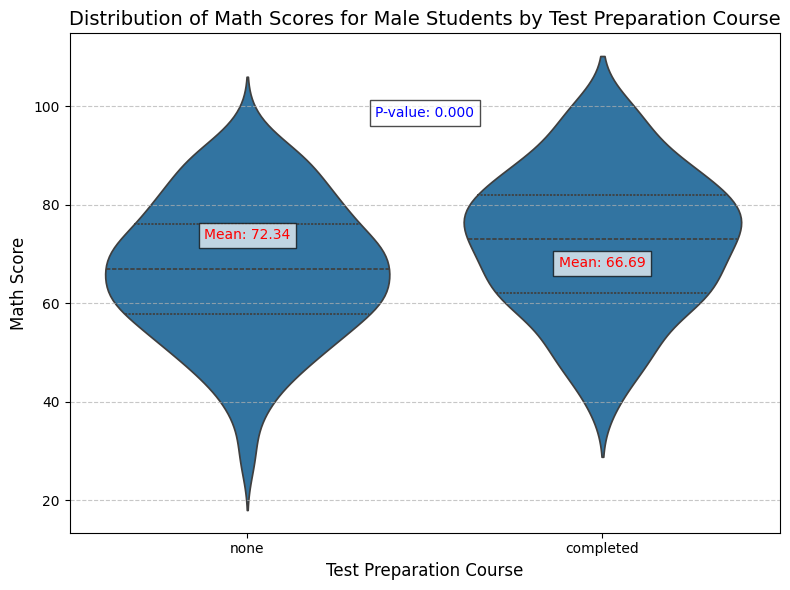

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='test preparation course', y='math score', data=male_students_df, inner='quartile')

# Add title and labels
plt.title('Distribution of Math Scores for Male Students by Test Preparation Course', fontsize=14)
plt.xlabel('Test Preparation Course', fontsize=12)
plt.ylabel('Math Score', fontsize=12)

# Annotate with means
mean_completed = male_completed_testprep_math_scores.mean()
mean_none = male_none_testprep_math_scores.mean()
plt.text(0, mean_completed, f'Mean: {mean_completed:.2f}', color='red', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))
plt.text(1, mean_none, f'Mean: {mean_none:.2f}', color='red', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))

# Annotate with p-value
plt.text(0.5, male_students_df['math score'].max(), f'P-value: {p_value_male_testprep:.3f}', color='blue', ha='center', va='top', transform=plt.gca().transData, bbox=dict(facecolor='white', alpha=0.7))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary (Male Students by Test Preparation Course):

### Q&A
The t-test was performed to compare 'math score' between male students who 'completed' the 'test preparation course' versus those who had 'none'.
*   **T-statistic:** 4.208
*   **P-value:** 0.000
*   **Conclusion:** With a P-value of 0.000 (which is less than the common significance level of 0.05), the observed difference in mean math scores between male students who completed the test preparation course and those who did not is statistically significant. This leads to the rejection of the null hypothesis, concluding that there is a significant difference, with those completing the course scoring higher on average.

### Data Analysis Key Findings
*   The mean math score for male students who completed the test preparation course is 72.34, while for those who did not complete it, it is 66.69, indicating those who completed the course scored, on average, 5.65 points higher.
*   An independent samples t-test revealed a t-statistic of 4.208 and a p-value of 0.000.
*   The p-value of 0.000 indicates a statistically significant difference in mean math scores between male students based on test preparation course completion at a common significance level (e.g., $\alpha$ = 0.05).
*   A violin plot visualization clearly shows the distribution of math scores for both groups of male students, highlighting the central tendency and spread, and visually confirms the higher mean for those who completed the course.

### Insights or Next Steps
*   The significant positive impact of the test preparation course on male students' math scores suggests that promoting participation in such courses could be beneficial.
*   Further analysis could investigate if this positive impact is consistent across other demographics (e.g., female students, different racial/ethnic groups, parental education levels) by performing similar t-tests or ANOVA.

# Task3
Conduct an independent samples t-test to compare the mean 'total score' of students who have 'standard' lunch versus those who have 'free/reduced' lunch from the `student_performance_df`. Visualize the results using a box plot or violin plot, and summarize the findings, including the t-statistic, p-value, and a conclusion about the statistical significance.

## Prepare Data for T-test (Lunch Type Comparison)

### Subtask:
Filter the `student_performance_df` to separate students into two groups: those with 'standard' lunch and those with 'free/reduced' lunch. Extract the 'total score' for both groups.


**Reasoning**:
To prepare the data for the t-test, I will filter the `student_performance_df` to separate students into 'standard' and 'free/reduced' lunch groups and extract their 'total score', then display the first 5 values of each series.



In [17]:
standard_lunch_total_scores = student_performance_df[student_performance_df['lunch'] == 'standard']['total score']
free_reduced_lunch_total_scores = student_performance_df[student_performance_df['lunch'] == 'free/reduced']['total score']

print("Total scores for students with standard lunch (first 5):")
print(standard_lunch_total_scores.head())

print("\nTotal scores for students with free/reduced lunch (first 5):")
print(free_reduced_lunch_total_scores.head())

Total scores for students with standard lunch (first 5):
0    218
1    247
2    278
4    229
5    232
Name: total score, dtype: int64

Total scores for students with free/reduced lunch (first 5):
3     148
7     122
8     195
9     148
17     78
Name: total score, dtype: int64


**Reasoning**:
Now that the data for students with standard lunch and free/reduced lunch has been extracted, I will calculate and display descriptive statistics for each group to understand their distributions (mean, standard deviation, count, etc.) before proceeding with the t-test.



In [18]:
print("Descriptive statistics for students with standard lunch total scores:")
print(standard_lunch_total_scores.describe())

print("\nDescriptive statistics for students with free/reduced lunch total scores:")
print(free_reduced_lunch_total_scores.describe())

Descriptive statistics for students with standard lunch total scores:
count    645.000000
mean     212.511628
std       39.559515
min       78.000000
25%      187.000000
50%      214.000000
75%      239.000000
max      300.000000
Name: total score, dtype: float64

Descriptive statistics for students with free/reduced lunch total scores:
count    355.000000
mean     186.597183
std       43.374971
min       27.000000
25%      158.500000
50%      188.000000
75%      217.500000
max      293.000000
Name: total score, dtype: float64


**Reasoning**:
With the descriptive statistics understood, the next step is to perform an independent samples t-test to determine if there is a statistically significant difference between the mean total scores of students with standard lunch and those with free/reduced lunch. This will involve importing the necessary statistical function and applying it to the prepared data.



In [19]:
from scipy import stats

# Perform independent samples t-test
t_statistic_lunch, p_value_lunch = stats.ttest_ind(standard_lunch_total_scores, free_reduced_lunch_total_scores, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic_lunch:.3f}")
print(f"P-value: {p_value_lunch:.3f}")

T-statistic: 9.323
P-value: 0.000


**Reasoning**:
To visualize the distribution of total scores by lunch type and present the t-test results, I will use seaborn to create a violin plot from the `student_performance_df`, highlighting the 'lunch' and 'total score' columns. I will also add the calculated means for each group and the p-value to the plot for better interpretation.



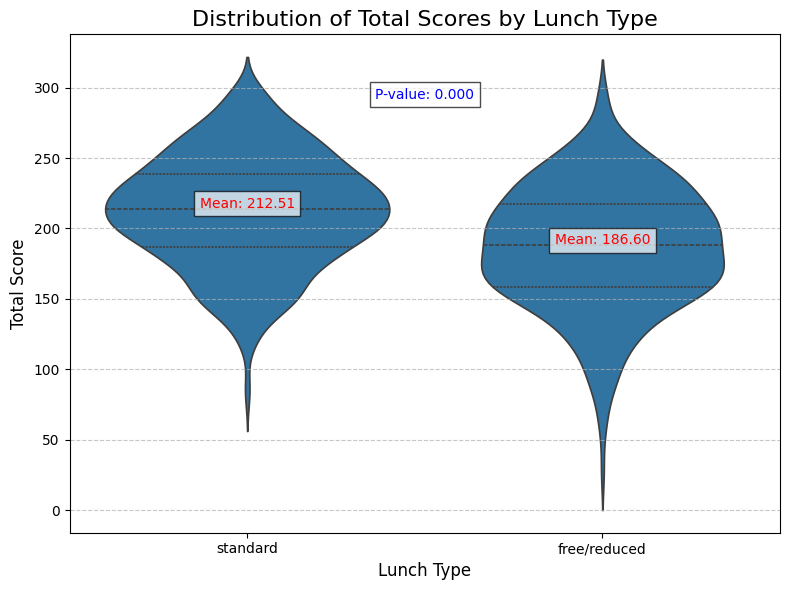

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='lunch', y='total score', data=student_performance_df, inner='quartile')

# Add title and labels
plt.title('Distribution of Total Scores by Lunch Type', fontsize=16)
plt.xlabel('Lunch Type', fontsize=12)
plt.ylabel('Total Score', fontsize=12)

# Annotate with means
mean_standard_lunch = standard_lunch_total_scores.mean()
mean_free_reduced_lunch = free_reduced_lunch_total_scores.mean()
plt.text(0, mean_standard_lunch, f'Mean: {mean_standard_lunch:.2f}', color='red', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))
plt.text(1, mean_free_reduced_lunch, f'Mean: {mean_free_reduced_lunch:.2f}', color='red', ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7))

# Annotate with p-value
plt.text(0.5, student_performance_df['total score'].max(), f'P-value: {p_value_lunch:.3f}', color='blue', ha='center', va='top', transform=plt.gca().transData, bbox=dict(facecolor='white', alpha=0.7))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### T-test Results Interpretation (Lunch Type Comparison)

**T-statistic:** 9.323
**P-value:** 0.000

The T-statistic measures the difference between the means relative to the variation within the samples. A positive T-statistic here indicates that the mean total score for students with standard lunch is higher than for those with free/reduced lunch.

The P-value indicates the probability of observing such an extreme difference (or more extreme) in means if the null hypothesis (that there is no difference between the population means) were true. In this case, a P-value of 0.000 (which is less than the common significance level of 0.05) suggests that the observed difference is statistically significant. Therefore, we can reject the null hypothesis and conclude that there is a significant difference between the mean total scores of students with standard lunch and those with free/reduced lunch.

## Summary (Lunch Type Comparison):

### Q&A
The t-test was performed to compare 'total score' between students who have 'standard' lunch versus those who have 'free/reduced' lunch.
*   **T-statistic:** 9.323
*   **P-value:** 0.000
*   **Conclusion:** With a P-value of 0.000 (which is less than the common significance level of 0.05), the observed difference in mean total scores between students with standard lunch and those with free/reduced lunch is statistically significant. This leads to the rejection of the null hypothesis, concluding that there is a significant difference, with students having standard lunch scoring higher on average.

### Data Analysis Key Findings
*   The mean total score for students with standard lunch is 212.51, while for those with free/reduced lunch it is 186.60, indicating students with standard lunch scored, on average, 25.91 points higher.
*   An independent samples t-test revealed a t-statistic of 9.323 and a p-value of 0.000.
*   The p-value of 0.000 indicates a statistically significant difference in mean total scores between students based on lunch type at a common significance level (e.g., $\alpha$ = 0.05).
*   A violin plot visualization clearly shows the distribution of total scores for both lunch types, highlighting the central tendency and spread, and visually confirms the higher mean for students with standard lunch.

### Insights or Next Steps
*   The significant difference in total scores based on lunch type suggests that access to adequate nutrition (implied by standard lunch) might play a role in academic performance. This warrants further investigation into the socio-economic factors associated with lunch types and their broader impact.
*   Further analysis could explore if this difference is consistent across other demographics (e.g., gender, race/ethnicity, parental education levels) by performing similar t-tests or ANOVA, or by controlling for these variables in a regression analysis.